# llama-bench Results

Analyses combined CSV outputs from `tests/run_llama_bench.py`, written to `tests/results/llama_bench/*.csv`.

This notebook is for **model / hardware throughput benchmarking**. Use the load-test notebooks for end-to-end API latency and slot behavior.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

RESULTS_DIR = Path('..') / 'tests' / 'results' / 'llama_bench'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

RUN_FILTER = None
CASE_FILTER = None

In [2]:
csv_files = sorted(RESULTS_DIR.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No llama-bench CSV files found in {RESULTS_DIR.resolve()}')

frames = [pd.read_csv(path) for path in csv_files]
data = pd.concat(frames, ignore_index=True)

if RUN_FILTER is not None:
    data = data[data['suite_run'] == RUN_FILTER].copy()

if CASE_FILTER is not None:
    data = data[data['case_label'].str.contains(CASE_FILTER, case=False, na=False)].copy()

data['avg_ts'] = pd.to_numeric(data['avg_ts'], errors='coerce')
data['stddev_ts'] = pd.to_numeric(data['stddev_ts'], errors='coerce')
data['n_prompt'] = pd.to_numeric(data['n_prompt'], errors='coerce').astype(int)
data['n_gen'] = pd.to_numeric(data['n_gen'], errors='coerce').astype(int)
data['model_size'] = pd.to_numeric(data['model_size'], errors='coerce')
data['workload'] = data['workload_label'].fillna('unknown')

print(f'Loaded {len(data)} llama-bench rows from {len(csv_files)} file(s)')
display(data[['suite_run', 'case_label', 'workload_label', 'cuda_visible_devices', 'split_mode_cfg', 'tensor_split_cfg', 'model_filename', 'n_prompt', 'n_gen', 'avg_ts']].sort_values(['case_label', 'workload_label']))

Loaded 15 llama-bench rows from 1 file(s)


,suite_run,case_label,workload_label,cuda_visible_devices,split_mode_cfg,tensor_split_cfg,model_filename,n_prompt,n_gen,avg_ts
0,2026-07-13_clean_full_run,gpt-oss-20b_1card,pp128,1,none,NaN,/opt/models/gpt-oss-20b-mxfp4.gguf,128,0,420.328064
2,2026-07-13_clean_full_run,gpt-oss-20b_1card,pp2048,1,none,NaN,/opt/models/gpt-oss-20b-mxfp4.gguf,2048,0,725.150092
1,2026-07-13_clean_full_run,gpt-oss-20b_1card,pp512,1,none,NaN,/opt/models/gpt-oss-20b-mxfp4.gguf,512,0,734.828178
3,2026-07-13_clean_full_run,gpt-oss-20b_1card,tg128,1,none,NaN,/opt/models/gpt-oss-20b-mxfp4.gguf,0,128,68.289102
4,2026-07-13_clean_full_run,gpt-oss-20b_1card,tg512,1,none,NaN,/opt/models/gpt-oss-20b-mxfp4.gguf,0,512,68.131051
5,2026-07-13_clean_full_run,gpt-oss-20b_2card_split,pp128,"1,2",layer,1/1,/opt/models/gpt-oss-20b-mxfp4.gguf,128,0,420.468605
7,2026-07-13_clean_full_run,gpt-oss-20b_2card_split,pp2048,"1,2",layer,1/1,/opt/models/gpt-oss-20b-mxfp4.gguf,2048,0,729.942839
6,2026-07-13_clean_full_run,gpt-oss-20b_2card_split,pp512,"1,2",layer,1/1,/opt/models/gpt-oss-20b-mxfp4.gguf,512,0,733.404737
8,2026-07-13_clean_full_run,gpt-oss-20b_2card_split,tg128,"1,2",layer,1/1,/opt/models/gpt-oss-20b-mxfp4.gguf,0,128,68.037804
9,2026-07-13_clean_full_run,gpt-oss-20b_2card_split,tg512,"1,2",layer,1/1,/opt/models/gpt-oss-20b-mxfp4.gguf,0,512,67.930653


## Summary table

`avg_ts` is the primary throughput metric reported by `llama-bench` in tokens per second.

In [3]:
summary = (
    data.groupby(['case_label', 'workload_label'])
    .agg(
        avg_ts=('avg_ts', 'mean'),
        stddev_ts=('stddev_ts', 'mean'),
        n_prompt=('n_prompt', 'first'),
        n_gen=('n_gen', 'first'),
        tensor_split=('tensor_split_cfg', 'first'),
        devices=('cuda_visible_devices', 'first'),
        rows=('avg_ts', 'size'),
    )
    .reset_index()
    .sort_values(['workload_label', 'avg_ts'], ascending=[True, False])
)
display(summary.round(3))

,case_label,workload_label,avg_ts,stddev_ts,n_prompt,n_gen,tensor_split,devices,rows
5,gpt-oss-20b_2card_split,pp128,420.469,12.203,128,0,1/1,"1,2",1
0,gpt-oss-20b_1card,pp128,420.328,12.203,128,0,NaN,1,1
10,qwen3.6-27b-q3_2card,pp128,109.798,0.067,128,0,1/1,"1,2",1
6,gpt-oss-20b_2card_split,pp2048,729.943,3.748,2048,0,1/1,"1,2",1
1,gpt-oss-20b_1card,pp2048,725.150,3.806,2048,0,NaN,1,1
11,qwen3.6-27b-q3_2card,pp2048,190.722,0.155,2048,0,1/1,"1,2",1
2,gpt-oss-20b_1card,pp512,734.828,6.953,512,0,NaN,1,1
7,gpt-oss-20b_2card_split,pp512,733.405,6.825,512,0,1/1,"1,2",1
12,qwen3.6-27b-q3_2card,pp512,138.214,0.315,512,0,1/1,"1,2",1
3,gpt-oss-20b_1card,tg128,68.289,0.047,0,128,NaN,1,1


## Plot 1: throughput by configuration and workload

Compares `llama-bench` throughput (`avg_ts`) across all benchmarked cases.

Saved figures/llama_bench_throughput.png


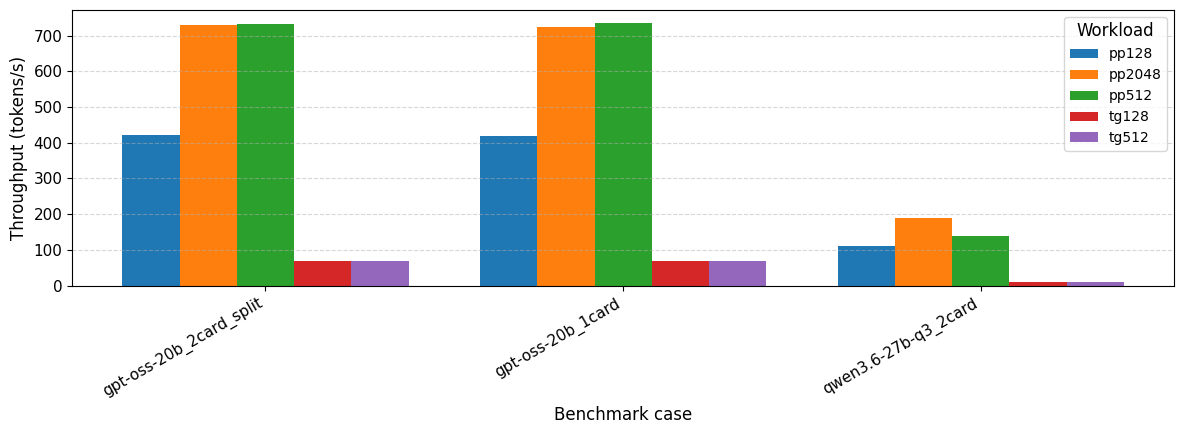

In [4]:
plot_df = summary.copy()
workloads = plot_df['workload_label'].unique().tolist()
cases = plot_df['case_label'].unique().tolist()
x = np.arange(len(cases))
width = 0.8 / max(len(workloads), 1)

fig, ax = plt.subplots(figsize=(12, 4.5))
cmap = plt.get_cmap('tab10')

for i, workload in enumerate(workloads):
    subset = plot_df[plot_df['workload_label'] == workload].set_index('case_label').reindex(cases).reset_index()
    offset = (i - (len(workloads) - 1) / 2) * width
    ax.bar(x + offset, subset['avg_ts'], width=width, label=workload, color=cmap(i))

ax.set_xticks(x)
ax.set_xticklabels(cases, rotation=30, ha='right')
ax.set_ylabel('Throughput (tokens/s)')
ax.set_xlabel('Benchmark case')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Workload')
fig.tight_layout()

out = FIGURES_DIR / 'llama_bench_throughput.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## Plot 2: prompt vs generation throughput

Separates prompt-processing (`pp*`) and generation (`tg*`) style workloads for easier comparison.

Saved figures/llama_bench_prompt_vs_gen.png


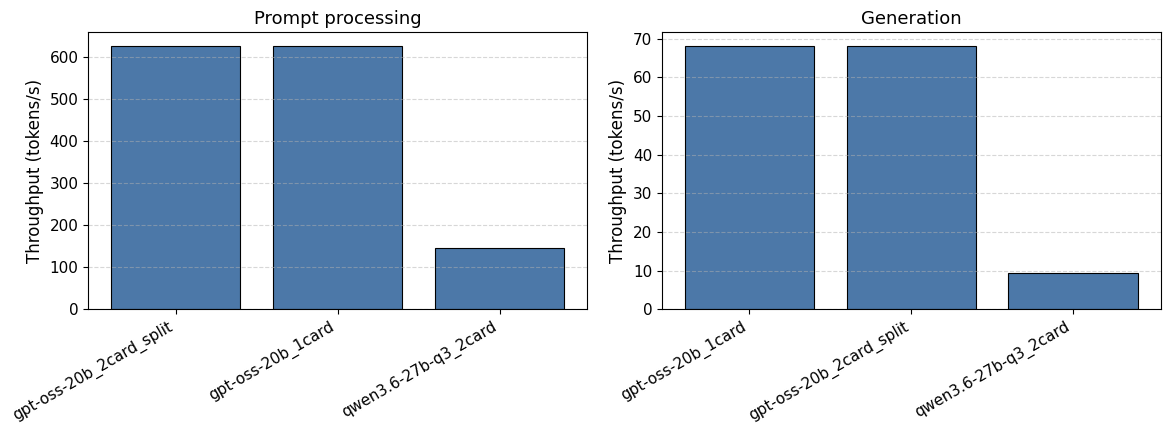

In [5]:
prompt_df = plot_df[plot_df['n_prompt'] > 0].copy()
gen_df = plot_df[plot_df['n_gen'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, subset, title in [
    (axes[0], prompt_df, 'Prompt processing'),
    (axes[1], gen_df, 'Generation'),
]:
    if subset.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    agg = subset.groupby('case_label')['avg_ts'].mean().sort_values(ascending=False)
    order = agg.index.tolist()
    x = np.arange(len(order))

    ax.bar(x, agg.values, color='#4C78A8', edgecolor='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=30, ha='right')
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylabel('Throughput (tokens/s)')

fig.tight_layout()
out = FIGURES_DIR / 'llama_bench_prompt_vs_gen.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()
